## Definisi Masalah :
Masalah yang ingin dianalisis dalam penelitian ini adalah bagaimana faktor-faktor lingkungan dan pertanian mempengaruhi produksi padi di Pulau Sumatera. Variabel yang dianalisis antara lain luas panen, curah hujan, kelembapan, dan suhu rata-rata. Fokus utama dari analisis ini adalah untuk mengidentifikasi faktor dominan yang mempengaruhi produksi padi, serta untuk memahami tren perubahan produksi selama 25 tahun terakhir.

Berdasarkan dataset yang ada, kita akan mengetahui :

- Korelasi antara produksi padi dengan variabel-variabel lainnya (luas panen, curah hujan, kelembapan, suhu rata-rata).
- Faktor apa yang paling berpengaruh terhadap produksi padi
- Tren produksi padi dalam kurun waktu 25 tahun, apakah terjadi peningkatan atau penurunan dalam periode tersebut.

Data source : https://www.kaggle.com/datasets/ardikasatria/datasettanamanpadisumatera

## Langkah 1 : Memuat Data dan Mengecek Informasi Data
Pada langkah pertama, saya memulai dengan memuat dataset yang berisi informasi tentang produksi padi di Pulau Sumatera. Dataset ini mencakup berbagai variabel terkait dengan hasil pertanian, seperti jumlah produksi, wilayah, tahun, dan faktor lainnya yang mempengaruhi hasil pertanian. Setelah memuat data tersebut menggunakan pustaka seperti pandas, saya menggunakan fungsi info() untuk memeriksa struktur dataset. Fungsi ini memberikan gambaran menyeluruh tentang tipe data masing-masing kolom dan jumlah total nilai yang ada.


In [ ]:
# impor modul pandas untuk mengolah data
import pandas as pd

# parse data
df = pd.read_csv('/content/Data_Tanaman_Padi_Sumatera_version_1.csv')

# cek informasi data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provinsi        224 non-null    object 
 1   Tahun           224 non-null    int64  
 2   Produksi        224 non-null    float64
 3   Luas Panen      224 non-null    float64
 4   Curah hujan     224 non-null    float64
 5   Kelembapan      224 non-null    float64
 6   Suhu rata-rata  224 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 12.4+ KB


In [ ]:
# cek isi data
df.head()

,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
0,Aceh,1993,1329536.0,323589.0,1627.0,82.00,26.06
1,Aceh,1994,1299699.0,329041.0,1521.0,82.12,26.92
2,Aceh,1995,1382905.0,339253.0,1476.0,82.72,26.27
3,Aceh,1996,1419128.0,348223.0,1557.0,83.00,26.08
4,Aceh,1997,1368074.0,337561.0,1339.0,82.46,26.31


## Langkah 2 :  Cek Statistik Deskriptif dan Nilai yang Hilang (Missing Value) serta Duplikasi
Langkah kedua melibatkan pengecekan statistik deskriptif untuk mendapatkan gambaran umum mengenai distribusi nilai pada setiap variabel. Saya menggunakan fungsi describe() untuk memperoleh statistik seperti mean, median, standar deviasi, dan range (min-max). Selanjutnya, saya memeriksa adanya missing values dan duplikasi dalam data. Berdasarkan hasil analisis, tidak ditemukan missing values atau data duplikat, sehingga data sudah bersih untuk analisis lebih lanjut.

In [ ]:
# cek statistik data
df.describe()

,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
count,224.000000,2.240000e+02,224.000000,224.000000,224.000000,224.000000
mean,2006.500000,1.679701e+06,374349.966920,2452.490759,80.948705,26.801964
std,8.095838,1.161387e+06,232751.161987,1031.972625,4.878680,1.197041
min,1993.000000,4.293800e+04,63142.040000,222.500000,54.200000,22.190000
25%,1999.750000,5.488570e+05,146919.500000,1703.525000,78.975000,26.177500
50%,2006.500000,1.667773e+06,373551.500000,2315.700000,82.375000,26.730000
75%,2013.250000,2.436851e+06,514570.250000,3039.700000,84.000000,27.200000
max,2020.000000,4.881089e+06,872737.000000,5522.000000,90.600000,29.850000


In [ ]:
# cek missing value
df.isnull().sum()

,0
Provinsi,0
Tahun,0
Produksi,0
Luas Panen,0
Curah hujan,0
Kelembapan,0
Suhu rata-rata,0


Setelah dicek, missing value pada semua kolom tidak ditemukan, artinya :
- Data lengkap : Tidak ada nilai yang hilang atau kosong dalam dataset, yang berarti setiap entri di setiap kolom memiliki nilai yang valid. Ini adalah kondisi ideal karena data yang lengkap memudahkan dalam analisis lebih lanjut.
- Tidak perlu penanganan missing value : Karena tidak ada nilai yang hilang, kamu tidak perlu melakukan proses seperti imputasi (mengisi nilai yang hilang dengan rata-rata, median, atau nilai lain) atau penghapusan baris/kolom yang mengandung missing values.

In [ ]:
# cek duplikasi pada data
print(f'Duplikasi pada data = {df.duplicated().sum()}')

Duplikasi pada data = 0


Setelah dicek, duplikasi dalam data adalah 0, itu berarti tidak ada data yang terduplikasi dalam dataset. Artinya, setiap baris dalam dataset memiliki nilai yang unik, dan tidak ada duplikasi data. Ini adalah kondisi yang baik karena data yang bebas dari duplikasi memungkinkan analisis yang lebih akurat dan efisien.

## Langkah 3 : Visualisasi Outlier Menggunakan Boxplot
Pada langkah ketiga, saya membuat visualisasi boxplot untuk mendeteksi adanya outlier di setiap variabel. Boxplot membantu mengidentifikasi nilai-nilai yang jauh di luar rentang normal, yang dapat mempengaruhi hasil analisis. Dari visualisasi ini, saya dapat dengan mudah melihat variabel yang memiliki potensi outlier dan memutuskan apakah perlu dilakukan penanganan lebih lanjut terhadap outlier tersebut.

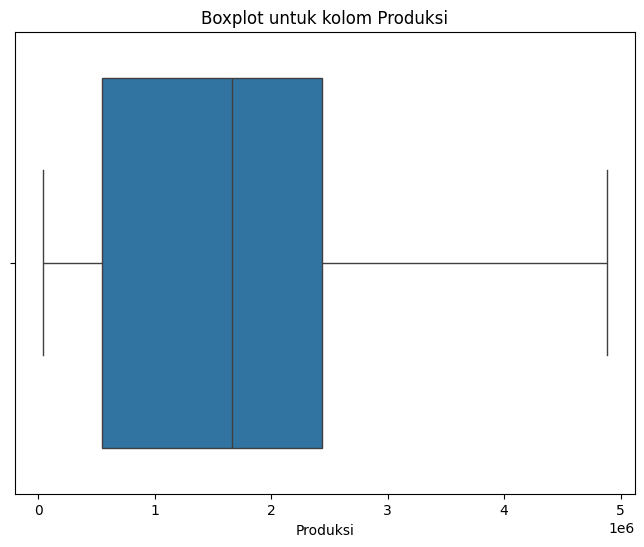

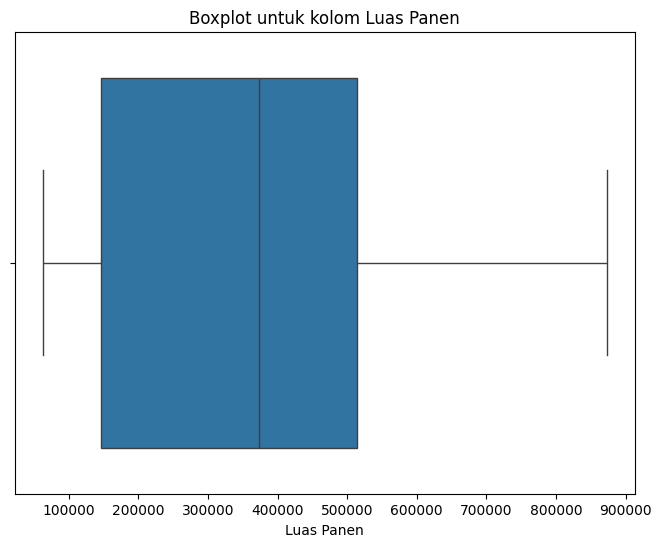

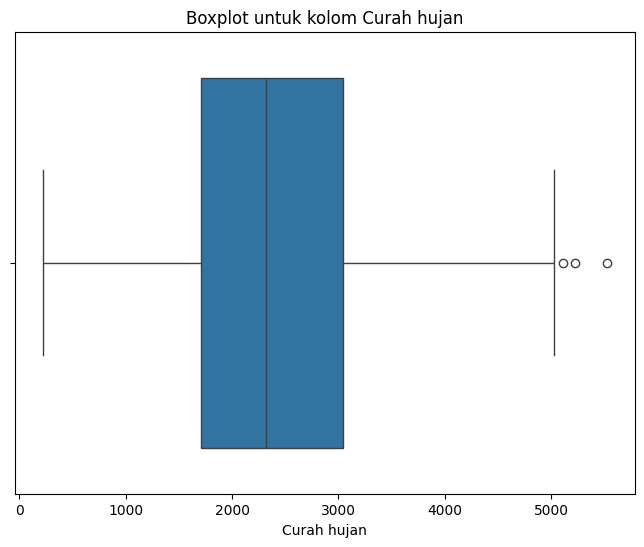

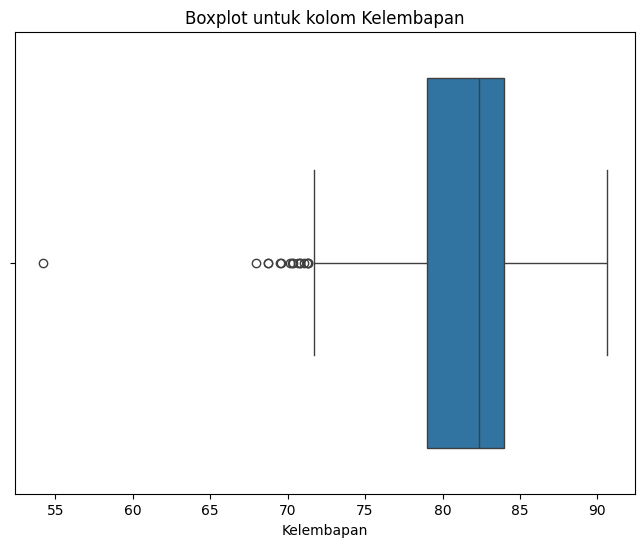

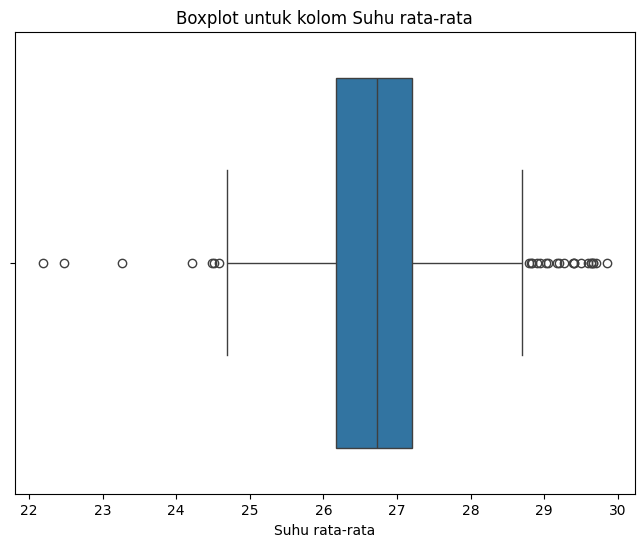

In [ ]:
# visualisasi outlier pada data menggunakan boxplot
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_plot = ['Produksi', 'Luas Panen', 'Curah hujan', 'Kelembapan', 'Suhu rata-rata']

for col in columns_to_plot:
    if col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot untuk kolom {col}')
        plt.show()

Berdasarkan analisis dataset yang memuat informasi mengenai produksi padi di Pulau Sumatera, ditemukan adanya outlier pada kolom curah hujan, kelembapan, dan suhu rata-rata. Namun, setelah mempertimbangkan konteks dan sifat data, outlier ini tidak memiliki dampak signifikan terhadap hasil analisis.

Hal ini disebabkan oleh fakta bahwa nilai ekstrem pada curah hujan, kelembapan, dan suhu rata-rata merupakan bagian dari fenomena alam yang wajar terjadi, seperti cuaca ekstrim yang memang dapat mempengaruhi pertanian, termasuk produksi padi. Oleh karena itu, outlier yang ditemukan dalam dataset ini mencerminkan kondisi yang relevan dan realistis dalam dunia pertanian, di mana cuaca ekstrim adalah faktor yang sering mempengaruhi hasil panen.

Dengan demikian, outlier pada dataset ini tidak dianggap sebagai kesalahan atau gangguan yang perlu dihapus, melainkan sebagai elemen yang dapat memberikan wawasan penting terkait pengaruh kondisi cuaca ekstrem terhadap produksi padi. Oleh karena itu, analisis dapat dilanjutkan tanpa menghilangkan outlier, dengan tetap memperhatikan faktor-faktor yang dapat mempengaruhi produksi padi secara signifikan.

## Langkah 4 : Visualisasi Korelasi Antar Variabel Menggunakan Heatmap
Langkah keempat melibatkan pembuatan visualisasi korelasi antar variabel dengan menggunakan heatmap korelasi. Heatmap ini menunjukkan sejauh mana setiap variabel saling berhubungan. Sebelum melakukan analisis korelasi, dilakukan pengecekan terhadap tipe data setiap kolom. Hal ini penting karena untuk melakukan perhitungan korelasi, data yang digunakan harus berupa nilai numerik. Setelah pengecekan, dipastikan bahwa semua kolom yang relevan memiliki tipe data yang sesuai (numerik), sehingga analisis korelasi antara produksi padi dan variabel lainnya dapat dilakukan dengan tepat dan valid.


Provinsi           object
Tahun               int64
Produksi          float64
Luas Panen        float64
Curah hujan       float64
Kelembapan        float64
Suhu rata-rata    float64
dtype: object


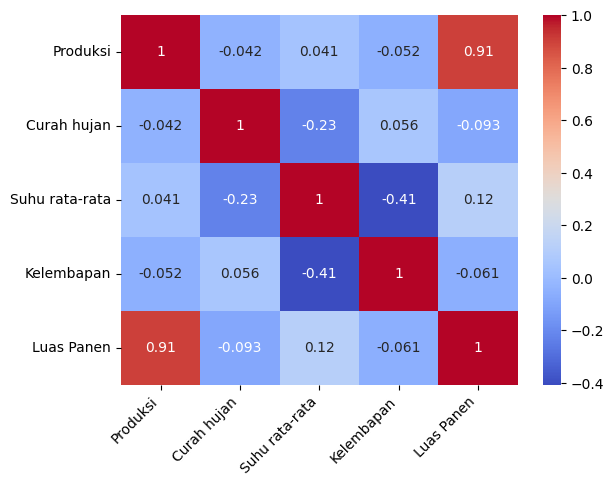

In [ ]:
# cek tipe data untuk dikorelasikan
df[['Produksi', 'Curah hujan', 'Suhu rata-rata', 'Kelembapan', 'Luas Panen']].dtypes
print(df.dtypes)
# visualisasi korelasi variabel dalam data menggunakan heatmap
correlation = df[['Produksi', 'Curah hujan', 'Suhu rata-rata', 'Kelembapan', 'Luas Panen']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

Berdasarkan hasil analisis korelasi menggunakan heatmap, dapat disimpulkan bahwa nilai korelasi yang mendekati 1 menunjukkan adanya hubungan positif yang kuat antara dua variabel, artinya kedua variabel bergerak searah. Sebaliknya, nilai korelasi yang mendekati -1 menunjukkan hubungan negatif yang kuat, di mana kedua variabel bergerak berlawanan arah. Korelasi yang mendekati 0 menandakan tidak ada hubungan yang signifikan antara variabel-variabel tersebut.

Dari hasil visualisasi, dapat dilihat bahwa terdapat korelasi positif yang cukup kuat antara Luas Panen dan Produksi padi. Ini menegaskan bahwa Luas Panen merupakan faktor dominan yang mempengaruhi produksi padi.

## Langkah 5 : Penguatan Hasil Analisis dengan Visualisasi Scatter Plot
Setelah melakukan visualisasi korelasi antar variabel menggunakan heatmap pada langkah sebelumnya, langkah selanjutnya adalah memperkuat hasil analisis tersebut dengan visualisasi menggunakan scatter plot. Heatmap menunjukkan bahwa produksi padi memiliki korelasi yang sangat kuat dan linier dengan luas panen, dibandingkan dengan faktor-faktor lainnya.

Untuk memperjelas temuan ini, dilakukan visualisasi dengan scatter plot, yang memetakan hubungan antara produksi padi dan variabel lainnya seperti curah hujan, kelembapan, dan suhu rata-rata.

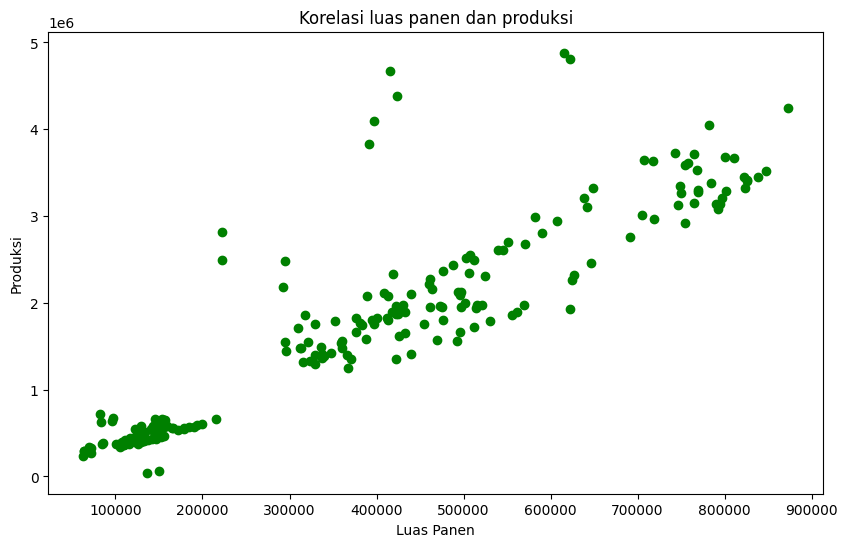

In [ ]:
# visualisasi korelasi produksi dan luas panen menggunakan scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df['Luas Panen'], df['Produksi'], color='g')
plt.title('Korelasi luas panen dan produksi')
plt.xlabel('Luas Panen')
plt.ylabel('Produksi')
plt.show()

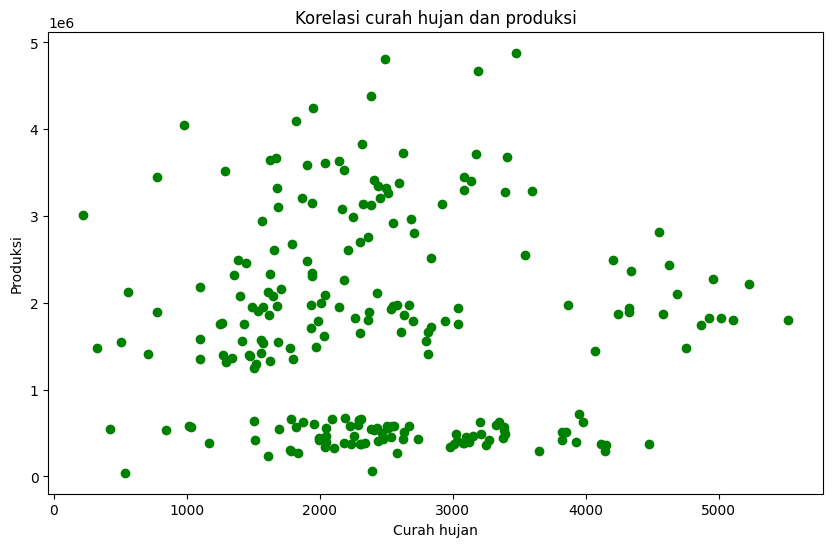

In [ ]:
# visualisasi korelasi produksi dan curah hujan
plt.figure(figsize=(10,6))
plt.scatter(df['Curah hujan'], df['Produksi'], color='g')
plt.title('Korelasi curah hujan dan produksi')
plt.xlabel('Curah hujan')
plt.ylabel('Produksi')
plt.show()

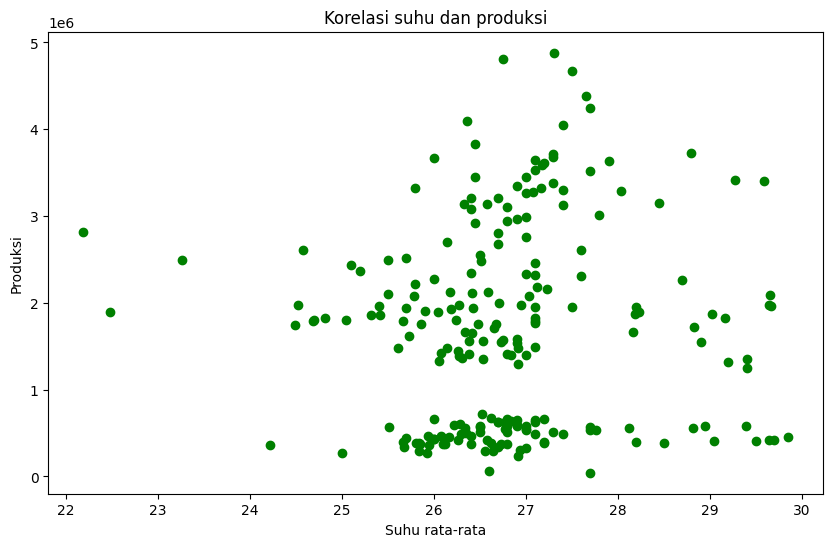

In [ ]:
# visualisasi korelasi produksi dan suhu rata-rata
plt.figure(figsize=(10,6))
plt.scatter(df['Suhu rata-rata'], df['Produksi'], color='g')
plt.title('Korelasi suhu dan produksi')
plt.xlabel('Suhu rata-rata')
plt.ylabel('Produksi')
plt.show()

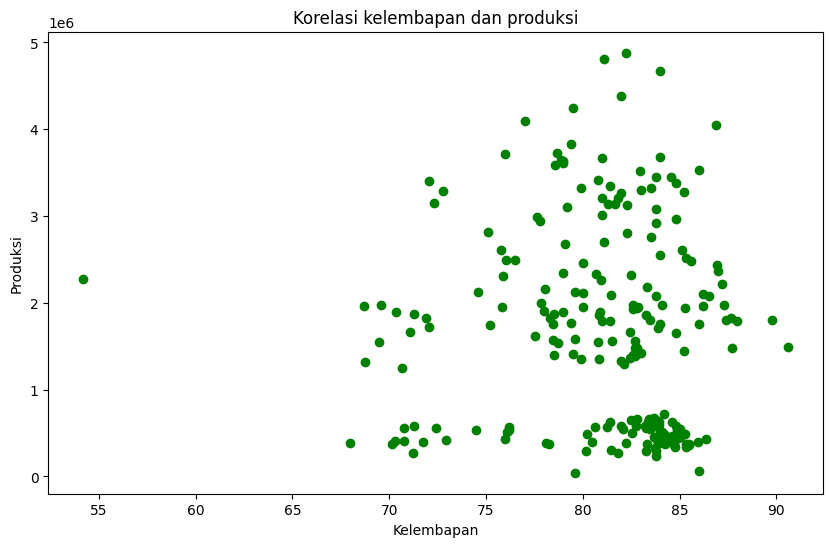

In [ ]:
# visualisasi korelasi Produksi dan luas panen
plt.figure(figsize=(10,6))
plt.scatter(df['Kelembapan'], df['Produksi'], color='g')
plt.title('Korelasi kelembapan dan produksi')
plt.xlabel('Kelembapan')
plt.ylabel('Produksi')
plt.show()

Hasilnya menunjukkan bahwa luas panen memang memiliki hubungan yang lebih jelas dan konsisten dengan produksi padi, sedangkan hubungan dengan faktor cuaca menunjukkan variasi yang lebih besar, meskipun tetap ada keterkaitan. Dengan scatter plot, pola hubungan ini menjadi lebih mudah dipahami dan memberikan konfirmasi visual terhadap hasil yang didapatkan dari heatmap.

Dengan kata lain, pada scatter plot yang memvisualisasikan hubungan antara produksi padi dan faktor cuaca, titik-titik data tidak membentuk pola yang sejelas atau seseragam hubungan antara produksi padi dan luas panen.

## Langkah 6 : Visualisasi Tren Produksi Padi dan Pertumbuhan Luas Panen dalam 25 Tahun di Pulau Sumatera
Untuk memperkuat bukti mengenai pengaruh luas panen terhadap produksi padi, langkah berikutnya adalah membuat visualisasi yang menggambarkan tren produksi padi dan pertumbuhan luas panen dalam kurun waktu 25 tahun.

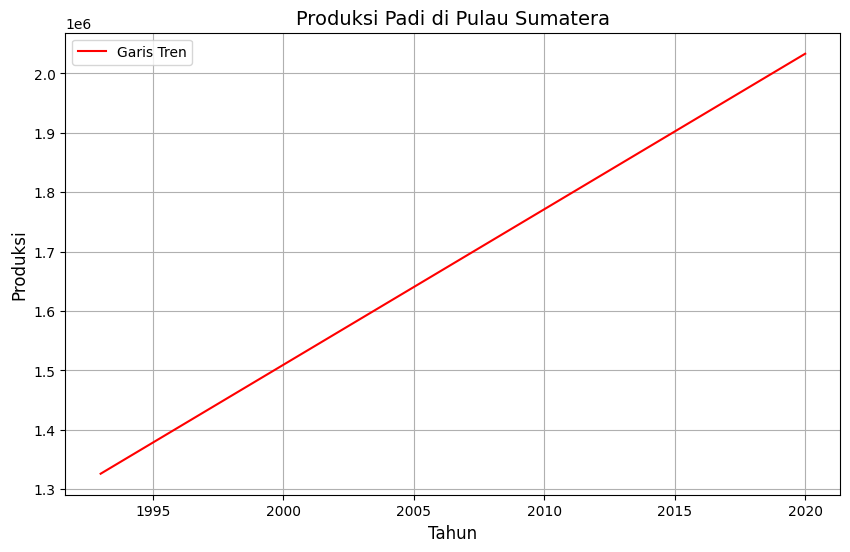

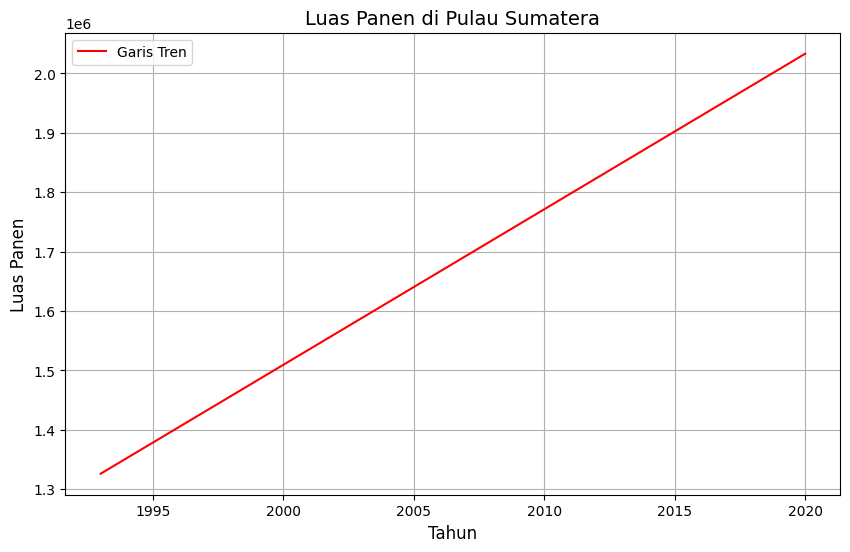

In [ ]:
from scipy.stats import linregress

# menghitung regresi linear
slope, intercept, r_value, p_value, std_err = linregress(df['Tahun'], df['Produksi'])

# tren produksi
plt.figure(figsize=(10, 6))
plt.plot(df['Tahun'], slope * df['Tahun'] + intercept, color='red', label='Garis Tren')

plt.title('Produksi Padi di Pulau Sumatera', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Produksi', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# tren luas panen
plt.figure(figsize=(10, 6))
plt.plot(df['Tahun'], slope * df['Tahun'] + intercept, color='red', label='Garis Tren')

plt.title('Luas Panen di Pulau Sumatera', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Luas Panen', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

Pada visualisasi pertama, tren produksi padi diperlihatkan dengan menggambarkan perubahan volume produksi padi dari tahun ke tahun. Visualisasi ini menunjukkan adanya kenaikan produksi padi yang konsisten sepanjang periode tersebut.

Kemudian, pada visualisasi kedua, pertumbuhan luas panen juga ditampilkan untuk menunjukkan bagaimana luas area yang ditanami padi terus meningkat selama 25 tahun tersebut. Tren ini semakin memperkuat temuan bahwa peningkatan luas panen secara langsung berkorelasi dengan peningkatan produksi padi.

Dengan kedua visualisasi ini, dapat disimpulkan bahwa peningkatan luas lahan pertanian padi memang menjadi faktor kunci dalam meningkatkan produksi padi, yang sekaligus memperlihatkan pentingnya ekspansi dan optimalisasi penggunaan lahan untuk sektor pertanian padi.

Mean Squared Error (MSE): 897358740900.6833
R-squared (R2): -0.014964185201382652


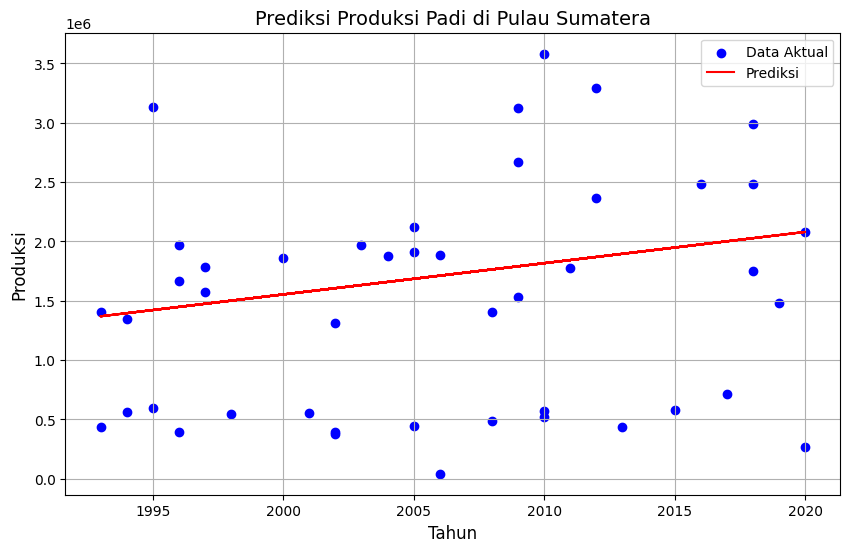

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Asumsikan df adalah DataFrame yang sudah ada
# Data yang digunakan untuk prediksi (misalnya 'Tahun' sebagai fitur dan 'Produksi' sebagai target)

# Membagi data menjadi fitur dan target
X = df[['Tahun']]  # Fitur, dalam hal ini kita menggunakan 'Tahun'
y = df['Produksi']  # Target, dalam hal ini kita menggunakan 'Produksi'

# Membagi data menjadi data pelatihan dan data pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membuat dan melatih model regresi linier
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi menggunakan model
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)

# Visualisasi hasil prediksi vs aktual
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Data Aktual')
plt.plot(X_test, y_pred, color='red', label='Prediksi')
plt.title('Prediksi Produksi Padi di Pulau Sumatera', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Produksi', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

## Implikasi Analisis :
Dari hasil analisis ini, dapat disimpulkan bahwa luas panen adalah faktor dominan yang mempengaruhi produksi padi di Pulau Sumatera. Hal ini terlihat jelas dari korelasi yang kuat antara keduanya, yang menunjukkan bahwa semakin besar luas area yang ditanami padi, semakin tinggi produksi yang dihasilkan. Dengan demikian, peningkatan luas panen menjadi kunci utama dalam meningkatkan hasil produksi padi secara keseluruhan.

Oleh karena itu, kebijakan yang mendukung perluasan lahan pertanian, seperti penyediaan akses lebih mudah ke lahan pertanian yang belum optimal, atau optimalisasi penggunaan lahan yang ada, akan sangat bermanfaat dalam meningkatkan produksi padi. Ini bisa mencakup program pemanfaatan lahan tidur, pemberian bantuan alat dan teknologi pertanian, atau meningkatkan kesuburan tanah agar lebih efisien dalam mendukung peningkatan produksi.

Meski faktor cuaca, seperti curah hujan, kelembapan, dan suhu rata-rata, juga berpengaruh terhadap produksi padi, namun pengaruhnya tidak sebesar luas panen. Variasi pada faktor cuaca lebih bersifat fluktuatif, dan meskipun dapat memengaruhi hasil panen, luas panen tetap menjadi faktor yang lebih signifikan dan dapat lebih mudah dikendalikan dalam upaya meningkatkan hasil pertanian secara lebih stabil dan terencana. Oleh karena itu, kebijakan yang memperhatikan faktor luas panen dan mendukung peningkatan kapasitas lahan pertanian akan memiliki dampak yang lebih besar dalam jangka panjang.

#### Analyzed by : Faiz Hauzan Musthafa


### Lets Connect on Social Media!
#####Linked In : https://bit.ly/FaizHauzanOnLinkedIn
#####Instagram : https://bit.ly/faizhauzann